"""The orchestrator-worker pattern is an agentic architecture where a central orchestrator LLM dynamically decomposes complex, unstructured tasks into subtasks, delegates them to specialized worker agents, and synthesizes their results into a final output.  Unlike static parallelization, this pattern determines the number and nature of subtasks at runtime based on the specific input, allowing for flexible handling of ambiguous or variable-complexity problems"""

In [1]:
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model
import os

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

model = init_chat_model("groq:qwen/qwen3.6-27b") 

e:\Agents\agent\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from typing import Annotated,List
import operator
from typing_extensions import Literal,TypedDict
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage,SystemMessage

In [15]:
class Section(BaseModel):
    name:str=Field(description="Name for this section of the report")
    description:str=Field(description="Brief overview of the main topics and concepts of the section")

class Sections(BaseModel):
    sections:List[Section]=Field(description="Exactly three sections for the report", min_length=3, max_length=3)

planner=model.with_structured_output(Sections)

In [22]:
# creating workers dynamically in langgraph (Send)
from langgraph.constants import Send

#graph state
class State(TypedDict):
    topic:str
    sections:List[Section]
    completed_sections:Annotated[list,operator.add]
    final_report:str

#WORKER STATE
class WorkerState(TypedDict):
    section:Section
    completed_sections:Annotated[list,operator.add]

C:\Users\Moham\AppData\Local\Temp\ipykernel_18864\1483494546.py:2: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


```mermaid
flowchart TD
    A[3 Sections] --> B[Send]

    B --> C[Worker 1<br/>Section 1]
    B --> D[Worker 2<br/>Section 2]
    B --> E[Worker 3<br/>Section 3]

    C --> F[Result 1]
    D --> G[Result 2]
    E --> H[Result 3]

    F --> I[operator.add]
    G --> I
    H --> I

    I --> J[All Results]
```

State = whole job. WorkerState = one worker's job. Send = gives the job to workers.

In [19]:
#nodes
def orchestrator(state:State):
    """Orchestrator that generates a plan for the report"""

    #generate queries
    report_sections=planner.invoke(
        [
            SystemMessage(content="Generate exactly 3 concise sections for the report. Return only the plan."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}")
        ]
    )

    print("Report Sections: ",report_sections)
    return {"sections":report_sections.sections}

def llm_call(state:WorkerState):
    """Worker writes a section of the report"""

    #generate section
    section=model.invoke(
        [
            SystemMessage(content="Write a concise report section, under 150 words, following the provided name and description. Include no preamble. Use markdown formatting."),
            HumanMessage(content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}")
        ],
        max_tokens=256
    )

    #write the updated section to completed sections
    return {"completed_sections":[section.content]}

#send
def assign_worker(state:State):
    """Assign a worker to each section in the plan"""

    #kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]

def synthesizer(state:State):
    """Synthesizer full report from sections"""

    #list of completed sections
    completed_sections=state["completed_sections"]

    #format completed section to str to use as context for final sections
    completed_report_sections="\n\n--\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}

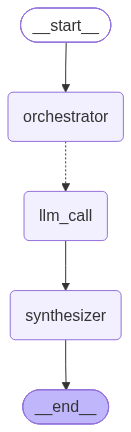

In [ ]:
from langgraph.graph import StateGraph, START, END
from IPython.display import display,Image,Markdown

# workflow = StateGraph(State)
# workflow.add_node("orchestrator", orchestrator)
# workflow.add_node("llm_call", llm_call)
# workflow.add_node("synthesizer", synthesizer)

# workflow.add_edge(START, "orchestrator")
# workflow.add_conditional_edges("orchestrator", assign_worker, ["llm_call"])
# workflow.add_edge("llm_call", "synthesizer")
# workflow.add_edge("synthesizer", END)

# orchestrator_worker=workflow.compile()

display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [ ]:
workflow = StateGraph(State)
workflow.add_node("orchestrator", orchestrator)
workflow.add_node("llm_call", llm_call)
workflow.add_node("synthesizer", synthesizer)
workflow.add_edge(START, "orchestrator")
workflow.add_conditional_edges("orchestrator", assign_worker, ["llm_call"])
workflow.add_edge("llm_call", "synthesizer")
workflow.add_edge("synthesizer", END)

orchestrator_worker=workflow.compile()
state=orchestrator_worker.invoke({"topic":"create a report on llm fine tuning"})
Markdown(state["final_report"])

Report Sections:  sections=[Section(name='Introduction to LLM Fine-Tuning', description='Overview of fine-tuning, its purpose, and the benefits of adapting pre-trained models to specific tasks.'), Section(name='Fine-Tuning Techniques and Approaches', description='Comparison of full fine-tuning versus Parameter-Efficient Fine-Tuning (PEFT) methods like LoRA and QLoRA.'), Section(name='Implementation and Best Practices', description='Key steps in the fine-tuning process, including data preparation, hyperparameter tuning, and model evaluation.')]
dict_keys(['topic', 'sections', 'completed_sections', 'final_report'])



<think>
Thinking Process:

1.  **Deconstruct the Request:**
    *   Goal: Write a concise report section.
    *   Length: Under 150 words.
    *   Name: "Introduction to LLM Fine-Tuning".
    *   Description: Overview of fine-tuning, its purpose, and benefits of adapting pre-trained models to specific tasks.
    *   Constraints: No preamble, use markdown formatting.

2.  **Drafting Content (Mental or rough text):**
    *   *Header:* # Introduction to LLM Fine-Tuning
    *   *Content:* Large Language Model (LLM) fine-tuning is the process of adapting a pre-trained model to a specific domain or task using a curated dataset. While pre-trained models possess broad general knowledge, fine-tuning aligns their behavior with specialized requirements, such as industry jargon, formatting constraints, or nuanced decision-making.
    *   *Purpose:* The primary purpose is to bridge the gap between general capability and specific application needs without the computational cost of training from scratch.
    *   *Benefits:* Key benefits include improved accuracy, reduced hallucination rates, and the ability to inject proprietary knowledge. This adaptation enhances model performance,

--


<think>
Thinking Process:

1.  **Deconstruct the Request:**
    *   Goal: Write a concise report section.
    *   Length: Under 150 words.
    *   Format: Markdown, no preamble.
    *   Section Name: Fine-Tuning Techniques and Approaches.
    *   Description: Comparison of full fine-tuning versus Parameter-Efficient Fine-Tuning (PEFT) methods like LoRA and QLoRA.

2.  **Drafting Content (Mental or rough text):**
    *   *Header:* `## Fine-Tuning Techniques and Approaches`
    *   *Content:* Need to compare Full FT vs. PEFT (LoRA/QLoRA).
    *   *Full FT:* Updates all parameters. High compute/memory cost. Best performance but expensive.
    *   *PEFT:* Updates few parameters. LoRA adds low-rank matrices. QLoRA uses quantization. Lower cost, efficient storage, comparable performance.
    *   *Drafting text:* "Fine-tuning strategies vary based on resource constraints and performance requirements. **Full fine-tuning** updates all model weights, offering maximum adaptability but demanding substantial computational power and memory

--


<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - **Section Name:** Implementation and Best Practices
   - **Description:** Key steps in the fine-tuning process, including data preparation, hyperparameter tuning, and model evaluation.
   - **Constraints:** Concise report section, under 150 words, no preamble, use markdown formatting.

2.  **Identify Key Requirements:**
   - Must be a report section titled "Implementation and Best Practices"
   - Must cover: data preparation, hyperparameter tuning, model evaluation
   - Must be under 150 words total
   - No introductory/preamble text (start directly with the section)
   - Use markdown formatting

3.  **Draft - Mental Refinement (aiming for conciseness & coverage):**
   ### Implementation and Best Practices
   Successful fine-tuning relies on a structured workflow beginning with rigorous data preparation. Curate high-quality, domain-specific datasets, ensuring balanced representation and thorough cleaning to eliminate noise and biases. Next, implement systematic hyperparameter tuning; prioritize learning rate, batch size, and number of epochs using grid or Bayesian optimization to balance convergence speed and generalization. Avoid overfitting by employing early